In [1]:
import torch
print(torch.cuda.is_available())		 # 查看GPu设备是否可用
print(torch.cuda.device_count()) 		 # 查看GPu设备数量
print(torch.cuda.get_device_name())   	 # 查看当前GPu设备名称，默认设备id从0开始
print(torch.cuda.current_device())

True
4
NVIDIA GeForce RTX 4090
0


In [15]:

import os
import random
import numpy as np
import torch
from exp.exp_short_term_forecasting import Exp_Short_Term_Forecast
from utils.tools import dotdict
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.task_name = 'short_term_forecast'
args.root_path = './dataset/m4/'
args.model_id='m4_Yearly'
args.model = 'AutoTimes_Gpt2'
args.data = 'm4'
args.is_training = 0
args.features = 'M'
args.seq_len = 672 # length of input（train） series
args.label_len = 576 # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96 # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96 # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 16
args.learning_rate = 0.0001
args.mlp_hidden_layers = 2
args.train_epochs = 10
args.use_amp = False
args.cosine = False
args.tmax = 10
args.mix_embeds = False
args.drop_last = False
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Yearly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 512
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'SMAPE'
args.lradj = 'type1'
args.weight_decay = 0.00001
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'task_name': 'short_term_forecast', 'root_path': './dataset/m4/', 'model_id': 'm4_Yearly', 'model': 'AutoTimes_Gpt2', 'data': 'm4', 'is_training': 0, 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 16, 'learning_rate': 0.0001, 'mlp_hidden_layers': 2, 'train_epochs': 10, 'use_amp': False, 'cosine': False, 'tmax': 10, 'mix_embeds': False, 'drop_last': False, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Yearly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 512, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'SMAPE', 'lradj': 'type1', 'weight_decay': 1e-05, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


In [16]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Short_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.task_name,
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

cuda:0
use mlp as tokenizer and detokenizer
>>>>>>>start training : short_term_forecast_m4_Yearly_AutoTimes_Gpt2_slm4_ll12_tl6_lr6_bt0.0001_wd16_hd1e-05_hl512_cos2_mixFalse_False>>>>>>>>>>>>>>>>>>>>>>>>>>
train 23000
val 23000
encoder.layers.0.weight torch.float32 torch.Size([512, 6])
encoder.layers.0.bias torch.float32 torch.Size([512])
encoder.layers.3.weight torch.float32 torch.Size([768, 512])
encoder.layers.3.bias torch.float32 torch.Size([768])
decoder.layers.0.weight torch.float32 torch.Size([512, 768])
decoder.layers.0.bias torch.float32 torch.Size([512])
decoder.layers.3.weight torch.float32 torch.Size([6, 512])
decoder.layers.3.bias torch.float32 torch.Size([6])
next learning rate is 0.0001
	iters: 100, epoch: 1 | loss: 8.1109200
	speed: 0.0389s/iter; left time: 555.5381s
	iters: 200, epoch: 1 | loss: 12.0582161
	speed: 0.0299s/iter; left time: 424.4569s
	iters: 300, epoch: 1 | loss: 11.7533731
	speed: 0.0300s/iter; left time: 423.1232s
	iters: 400, epoch: 1 | loss: 10.334974

In [17]:

import os
import random
import numpy as np
import torch
from exp.exp_short_term_forecasting import Exp_Short_Term_Forecast
from utils.tools import dotdict
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.task_name = 'short_term_forecast'
args.root_path = './dataset/m4/'
args.model_id='m4_Quarterly'
args.model = 'AutoTimes_Gpt2'
args.data = 'm4'
args.is_training = 0
args.features = 'M'
args.seq_len = 672 # length of input（train） series
args.label_len = 576 # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96 # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96 # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 16
args.learning_rate = 0.00005
args.mlp_hidden_layers = 2
args.train_epochs = 10
args.use_amp = False
args.cosine = False
args.tmax = 10
args.mix_embeds = False
args.drop_last = False
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Quarterly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 512
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'SMAPE'
args.lradj = 'type1'
args.weight_decay = 0.000005
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'task_name': 'short_term_forecast', 'root_path': './dataset/m4/', 'model_id': 'm4_Quarterly', 'model': 'AutoTimes_Gpt2', 'data': 'm4', 'is_training': 0, 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 16, 'learning_rate': 5e-05, 'mlp_hidden_layers': 2, 'train_epochs': 10, 'use_amp': False, 'cosine': False, 'tmax': 10, 'mix_embeds': False, 'drop_last': False, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Quarterly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 512, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'SMAPE', 'lradj': 'type1', 'weight_decay': 5e-06, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


In [18]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Short_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.task_name,
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

cuda:0
use mlp as tokenizer and detokenizer
>>>>>>>start training : short_term_forecast_m4_Quarterly_AutoTimes_Gpt2_slm4_ll16_tl8_lr8_bt5e-05_wd16_hd5e-06_hl512_cos2_mixFalse_False>>>>>>>>>>>>>>>>>>>>>>>>>>
train 24000
val 24000
encoder.layers.0.weight torch.float32 torch.Size([512, 8])
encoder.layers.0.bias torch.float32 torch.Size([512])
encoder.layers.3.weight torch.float32 torch.Size([768, 512])
encoder.layers.3.bias torch.float32 torch.Size([768])
decoder.layers.0.weight torch.float32 torch.Size([512, 768])
decoder.layers.0.bias torch.float32 torch.Size([512])
decoder.layers.3.weight torch.float32 torch.Size([8, 512])
decoder.layers.3.bias torch.float32 torch.Size([8])
next learning rate is 5e-05
	iters: 100, epoch: 1 | loss: 5.8231754
	speed: 0.0395s/iter; left time: 587.9966s
	iters: 200, epoch: 1 | loss: 16.6332531
	speed: 0.0316s/iter; left time: 467.8649s
	iters: 300, epoch: 1 | loss: 8.6364908
	speed: 0.0315s/iter; left time: 462.9221s
	iters: 400, epoch: 1 | loss: 8.4778366

In [1]:

import os
import random
import numpy as np
import torch
from exp.exp_short_term_forecasting import Exp_Short_Term_Forecast
from utils.tools import dotdict

fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.task_name = 'short_term_forecast'
args.root_path = './dataset/m4/'
args.model_id = 'm4_Monthly'
args.model = 'AutoTimes_Gpt2'
args.data = 'm4'
args.is_training = 0
args.features = 'M'
args.seq_len = 672  # length of input（train） series
args.label_len = 576  # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96  # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96  # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 16
args.learning_rate = 0.00005
args.mlp_hidden_layers = 2
args.train_epochs = 10
args.use_amp = False
args.cosine = False
args.tmax = 10
args.mix_embeds = False
args.drop_last = False
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Monthly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 1024
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'SMAPE'
args.lradj = 'type1'
args.weight_decay = 0.000001
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'task_name': 'short_term_forecast', 'root_path': './dataset/m4/', 'model_id': 'm4_Monthly', 'model': 'AutoTimes_Gpt2', 'data': 'm4', 'is_training': 0, 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 16, 'learning_rate': 5e-05, 'mlp_hidden_layers': 2, 'train_epochs': 10, 'use_amp': False, 'cosine': False, 'tmax': 10, 'mix_embeds': False, 'drop_last': False, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Monthly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 1024, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'SMAPE', 'lradj': 'type1', 'weight_decay': 1e-06, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


In [2]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Short_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.task_name,
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

cuda:0
use mlp as tokenizer and detokenizer
>>>>>>>start training : short_term_forecast_m4_Monthly_AutoTimes_Gpt2_slm4_ll36_tl18_lr18_bt5e-05_wd16_hd1e-06_hl1024_cos2_mixFalse_False>>>>>>>>>>>>>>>>>>>>>>>>>>
train 48000
val 48000
encoder.layers.0.weight torch.float32 torch.Size([1024, 18])
encoder.layers.0.bias torch.float32 torch.Size([1024])
encoder.layers.3.weight torch.float32 torch.Size([768, 1024])
encoder.layers.3.bias torch.float32 torch.Size([768])
decoder.layers.0.weight torch.float32 torch.Size([1024, 768])
decoder.layers.0.bias torch.float32 torch.Size([1024])
decoder.layers.3.weight torch.float32 torch.Size([18, 1024])
decoder.layers.3.bias torch.float32 torch.Size([18])
next learning rate is 5e-05
	iters: 100, epoch: 1 | loss: 11.4129152
	speed: 0.0358s/iter; left time: 1070.0186s
	iters: 200, epoch: 1 | loss: 9.7129669
	speed: 0.0296s/iter; left time: 882.3570s
	iters: 300, epoch: 1 | loss: 10.5915480
	speed: 0.0284s/iter; left time: 842.8138s
	iters: 400, epoch: 1 | los

In [3]:

import os
import random
import numpy as np
import torch
from exp.exp_short_term_forecasting import Exp_Short_Term_Forecast
from utils.tools import dotdict

fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.task_name = 'short_term_forecast'
args.root_path = './dataset/m4/'
args.model_id = 'm4_Weekly'
args.model = 'AutoTimes_Gpt2'
args.data = 'm4'
args.is_training = 0
args.features = 'M'
args.seq_len = 672  # length of input（train） series
args.label_len = 576  # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96  # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96  # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 16
args.learning_rate = 0.0001
args.mlp_hidden_layers = 2
args.train_epochs = 10
args.use_amp = False
args.cosine = False
args.tmax = 10
args.mix_embeds = False
args.drop_last = False
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Weekly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 1024
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'SMAPE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'task_name': 'short_term_forecast', 'root_path': './dataset/m4/', 'model_id': 'm4_Weekly', 'model': 'AutoTimes_Gpt2', 'data': 'm4', 'is_training': 0, 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 16, 'learning_rate': 0.0001, 'mlp_hidden_layers': 2, 'train_epochs': 10, 'use_amp': False, 'cosine': False, 'tmax': 10, 'mix_embeds': False, 'drop_last': False, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Weekly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 1024, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'SMAPE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


In [4]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Short_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.task_name,
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

cuda:0
use mlp as tokenizer and detokenizer
>>>>>>>start training : short_term_forecast_m4_Weekly_AutoTimes_Gpt2_slm4_ll26_tl13_lr13_bt0.0001_wd16_hd0_hl1024_cos2_mixFalse_False>>>>>>>>>>>>>>>>>>>>>>>>>>
train 359
val 359
encoder.layers.0.weight torch.float32 torch.Size([1024, 13])
encoder.layers.0.bias torch.float32 torch.Size([1024])
encoder.layers.3.weight torch.float32 torch.Size([768, 1024])
encoder.layers.3.bias torch.float32 torch.Size([768])
decoder.layers.0.weight torch.float32 torch.Size([1024, 768])
decoder.layers.0.bias torch.float32 torch.Size([1024])
decoder.layers.3.weight torch.float32 torch.Size([13, 1024])
decoder.layers.3.bias torch.float32 torch.Size([13])
next learning rate is 0.0001
Epoch: 1 cost time: 1.3680758476257324
Epoch: 1, Steps: 23 | Train Loss: 9.8798884 Vali Loss: 12.6283339 Test Loss: 12.6283339
Validation loss decreased (inf --> 12.628334).
next learning rate is 0.0001
Epoch: 2 cost time: 1.3023595809936523
Epoch: 2, Steps: 23 | Train Loss: 8.8085533 

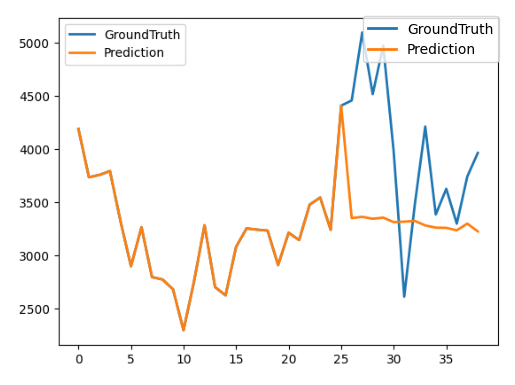

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
img = Image.open('/root/AutoTimes-main/test_results/short_term_forecast_m4_Weekly_AutoTimes_Gpt2_slm4_ll26_tl13_lr13_bt0.0001_wd16_hd0_hl1024_cos2_mixFalse_False/358.png')
# 使用matplotlib显示图片
plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:

import os
import random
import numpy as np
import torch
from exp.exp_short_term_forecasting import Exp_Short_Term_Forecast
from utils.tools import dotdict

fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.task_name = 'short_term_forecast'
args.root_path = './dataset/m4/'
args.model_id = 'm4_Daily'
args.model = 'AutoTimes_Gpt2'
args.data = 'm4'
args.is_training = 0
args.features = 'M'
args.seq_len = 672  # length of input（train） series
args.label_len = 576  # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96  # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96  # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 16
args.learning_rate = 0.0005
args.mlp_hidden_layers = 2
args.train_epochs = 10
args.use_amp = False
args.cosine = False
args.tmax = 10
args.mix_embeds = False
args.drop_last = False
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Daily'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 1024
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'SMAPE'
args.lradj = 'type1'
args.weight_decay = 0.000005
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'task_name': 'short_term_forecast', 'root_path': './dataset/m4/', 'model_id': 'm4_Daily', 'model': 'AutoTimes_Gpt2', 'data': 'm4', 'is_training': 0, 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 16, 'learning_rate': 0.0005, 'mlp_hidden_layers': 2, 'train_epochs': 10, 'use_amp': False, 'cosine': False, 'tmax': 10, 'mix_embeds': False, 'drop_last': False, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Daily', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 1024, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'SMAPE', 'lradj': 'type1', 'weight_decay': 5e-06, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


cuda:0
use mlp as tokenizer and detokenizer
>>>>>>>start training : short_term_forecast_m4_Daily_AutoTimes_Gpt2_slm4_ll28_tl14_lr14_bt0.0005_wd16_hd5e-06_hl1024_cos2_mixFalse_False>>>>>>>>>>>>>>>>>>>>>>>>>>
train 4227
val 4227
encoder.layers.0.weight torch.float32 torch.Size([1024, 14])
encoder.layers.0.bias torch.float32 torch.Size([1024])
encoder.layers.3.weight torch.float32 torch.Size([768, 1024])
encoder.layers.3.bias torch.float32 torch.Size([768])
decoder.layers.0.weight torch.float32 torch.Size([1024, 768])
decoder.layers.0.bias torch.float32 torch.Size([1024])
decoder.layers.3.weight torch.float32 torch.Size([14, 1024])
decoder.layers.3.bias torch.float32 torch.Size([14])
next learning rate is 0.0005
	iters: 100, epoch: 1 | loss: 1.8955016
	speed: 0.0367s/iter; left time: 93.6228s
	iters: 200, epoch: 1 | loss: 1.8962164
	speed: 0.0301s/iter; left time: 73.6822s
Epoch: 1 cost time: 8.744219779968262
Epoch: 1, Steps: 265 | Train Loss: 2.3879111 Vali Loss: 3.4907572 Test Loss: 3.

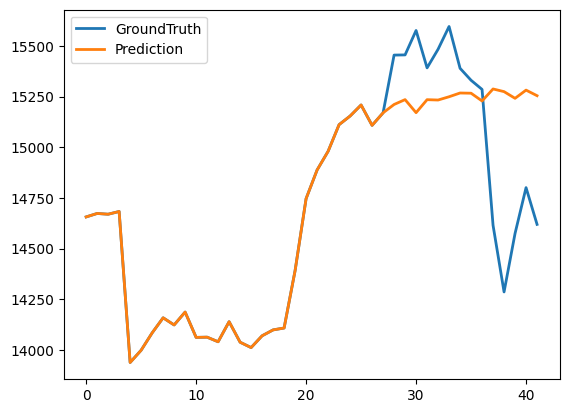

In [7]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Short_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.task_name,
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

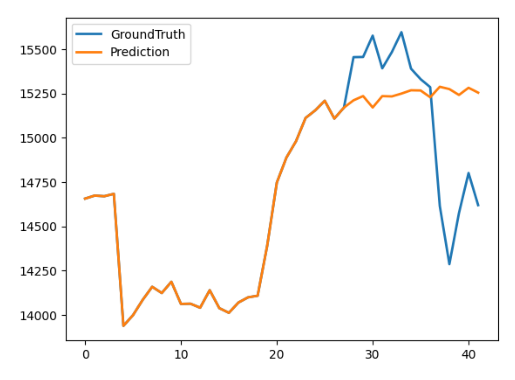

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
img = Image.open('/root/AutoTimes-main/test_results/short_term_forecast_m4_Daily_AutoTimes_Gpt2_slm4_ll28_tl14_lr14_bt0.0005_wd16_hd5e-06_hl1024_cos2_mixFalse_False/4226.png')
# 使用matplotlib显示图片
plt.imshow(img)
plt.axis('off')
plt.show()

In [1]:

import os
import random
import numpy as np
import torch
from exp.exp_short_term_forecasting import Exp_Short_Term_Forecast
from utils.tools import dotdict

fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

args = dotdict()
args.task_name = 'short_term_forecast'
args.root_path = './dataset/m4/'
args.model_id = 'm4_Hourly'
args.model = 'AutoTimes_Gpt2'
args.data = 'm4'
args.is_training = 0
args.features = 'M'
args.seq_len = 672  # length of input（train） series
args.label_len = 576  # length of prefix of decoder（decoder 用的前缀长度）
args.token_len = 96  # 模型每次预测长度（AutoTimes 的预测是 token_len 为窗口的多步滚动预测）
args.test_seq_len = 672
args.test_label_len = 576
args.test_pred_len = 96  # test_pred_len 可能不是 token_len 的整数倍 → 需要多轮推理
args.batch_size = 16
args.learning_rate = 0.0001
args.mlp_hidden_layers = 2
args.train_epochs = 10
args.use_amp = False
args.cosine = False
args.tmax = 10
args.mix_embeds = False
args.drop_last = False
args.checkpoints = './checkpoints/'
args.val_set_shuffle = True
args.seasonal_patterns = 'Hourly'
args.dropout = 0.1
args.llm_ckp_dir = './gpt2'
args.mlp_hidden_dim = 1024
args.mlp_activation = 'tanh'
args.num_workers = 10
args.patience = 3
args.des = 'test'
args.loss = 'SMAPE'
args.lradj = 'type1'
args.weight_decay = 0
args.test_dir = './test'
args.test_file_name = 'checkpoint.pth'
args.gpu = 0
args.visualize = True
print('Args in experiment:')
print(args)

Args in experiment:
{'task_name': 'short_term_forecast', 'root_path': './dataset/m4/', 'model_id': 'm4_Hourly', 'model': 'AutoTimes_Gpt2', 'data': 'm4', 'is_training': 0, 'features': 'M', 'seq_len': 672, 'label_len': 576, 'token_len': 96, 'test_seq_len': 672, 'test_label_len': 576, 'test_pred_len': 96, 'batch_size': 16, 'learning_rate': 0.0001, 'mlp_hidden_layers': 2, 'train_epochs': 10, 'use_amp': False, 'cosine': False, 'tmax': 10, 'mix_embeds': False, 'drop_last': False, 'checkpoints': './checkpoints/', 'val_set_shuffle': True, 'seasonal_patterns': 'Hourly', 'dropout': 0.1, 'llm_ckp_dir': './gpt2', 'mlp_hidden_dim': 1024, 'mlp_activation': 'tanh', 'num_workers': 10, 'patience': 3, 'des': 'test', 'loss': 'SMAPE', 'lradj': 'type1', 'weight_decay': 0, 'test_dir': './test', 'test_file_name': 'checkpoint.pth', 'gpu': 0, 'visualize': True}


In [2]:

os.environ["CUDA_VISIBLE_DEVICES"] = '0'
exp = Exp_Short_Term_Forecast(args)
# setting record of experiments
setting = '{}_{}_{}_sl{}_ll{}_tl{}_lr{}_bt{}_wd{}_hd{}_hl{}_cos{}_mix{}_{}'.format(
    args.task_name,
    args.model_id,
    args.model,
    args.data,
    args.seq_len,
    args.label_len,
    args.token_len,
    args.learning_rate,
    args.batch_size,
    args.weight_decay,
    args.mlp_hidden_dim,
    args.mlp_hidden_layers,
    args.cosine,
    args.mix_embeds,
    args.des)
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
exp.train(setting)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
exp.test(setting)
torch.cuda.empty_cache()

cuda:0
use mlp as tokenizer and detokenizer
>>>>>>>start training : short_term_forecast_m4_Hourly_AutoTimes_Gpt2_slm4_ll96_tl48_lr48_bt0.0001_wd16_hd0_hl1024_cos2_mixFalse_False>>>>>>>>>>>>>>>>>>>>>>>>>>
train 414
val 414
encoder.layers.0.weight torch.float32 torch.Size([1024, 48])
encoder.layers.0.bias torch.float32 torch.Size([1024])
encoder.layers.3.weight torch.float32 torch.Size([768, 1024])
encoder.layers.3.bias torch.float32 torch.Size([768])
decoder.layers.0.weight torch.float32 torch.Size([1024, 768])
decoder.layers.0.bias torch.float32 torch.Size([1024])
decoder.layers.3.weight torch.float32 torch.Size([48, 1024])
decoder.layers.3.bias torch.float32 torch.Size([48])
next learning rate is 0.0001
Epoch: 1 cost time: 1.4374608993530273
Epoch: 1, Steps: 26 | Train Loss: 34.3469805 Vali Loss: 33.0845382 Test Loss: 33.0845382
Validation loss decreased (inf --> 33.084538).
next learning rate is 0.0001
Epoch: 2 cost time: 1.137190580368042
Epoch: 2, Steps: 26 | Train Loss: 31.1146429

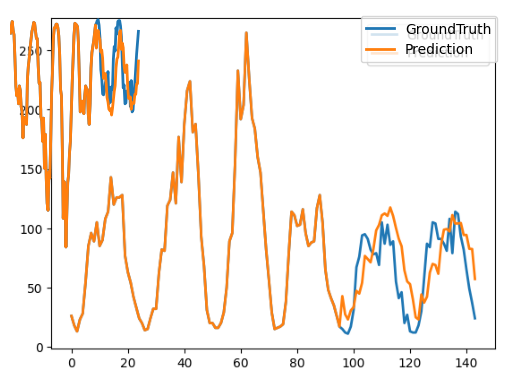

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline
img = Image.open('/root/AutoTimes-main/test_results/short_term_forecast_m4_Hourly_AutoTimes_Gpt2_slm4_ll96_tl48_lr48_bt0.0001_wd16_hd0_hl1024_cos2_mixFalse_False/413.png')
# 使用matplotlib显示图片
plt.imshow(img)
plt.axis('off') 
plt.show()